In [1]:
import os
import pandas as pd

def load_all_leadlag_pairs(metric, k=5):
    """
    Carrega todos os pares de decis (1v10, 2v9, etc) para uma métrica específica.
    Retorna um dicionário: { 'd1_d10': df, 'd2_d9': df, ... }
    """
    decile_pairs = [(i, 11 - i) for i in range(1, 6)]
    all_pairs_data = {}

    for p_idx, c_idx in decile_pairs:
        pair_key = f"d{p_idx}_d{c_idx}"
        df_list = []
        
        for year in range(2014, 2026):
            # Seguindo o padrão de nome: leadlag_hrm_2024_5_d1_d10.csv
            file_path = f"../../data/08_lead_lag/leadlag_{metric}_{year}_{k}_{pair_key}.csv"
            
            if os.path.exists(file_path):
                df_temp = pd.read_csv(file_path, index_col=0)
                df_list.append(df_temp)
        
        if df_list:
            all_pairs_data[pair_key] = pd.concat(df_list).sort_index()
        else:
            print(f"Aviso: Par {pair_key} não encontrado para a métrica {metric}")
            
    return all_pairs_data

# 1. Carregando tudo
# hrm_results e pozzi_results serão dicionários com 5 DataFrames cada
hrm_results = load_all_leadlag_pairs("hrm", k=5)
pozzi_results = load_all_leadlag_pairs("pozzi", k=5)

# 2. Exemplo de como acessar um par específico:
# df_hrm_extremos = hrm_results['d1_d10']
# df_pozzi_extremos = pozzi_results['d1_d10']

print(f"Pares carregados para HRM: {list(hrm_results.keys())}")
print(f"Pares carregados para Pozzi: {list(pozzi_results.keys())}")

Pares carregados para HRM: ['d1_d10', 'd2_d9', 'd3_d8', 'd4_d7', 'd5_d6']
Pares carregados para Pozzi: ['d1_d10', 'd2_d9', 'd3_d8', 'd4_d7', 'd5_d6']


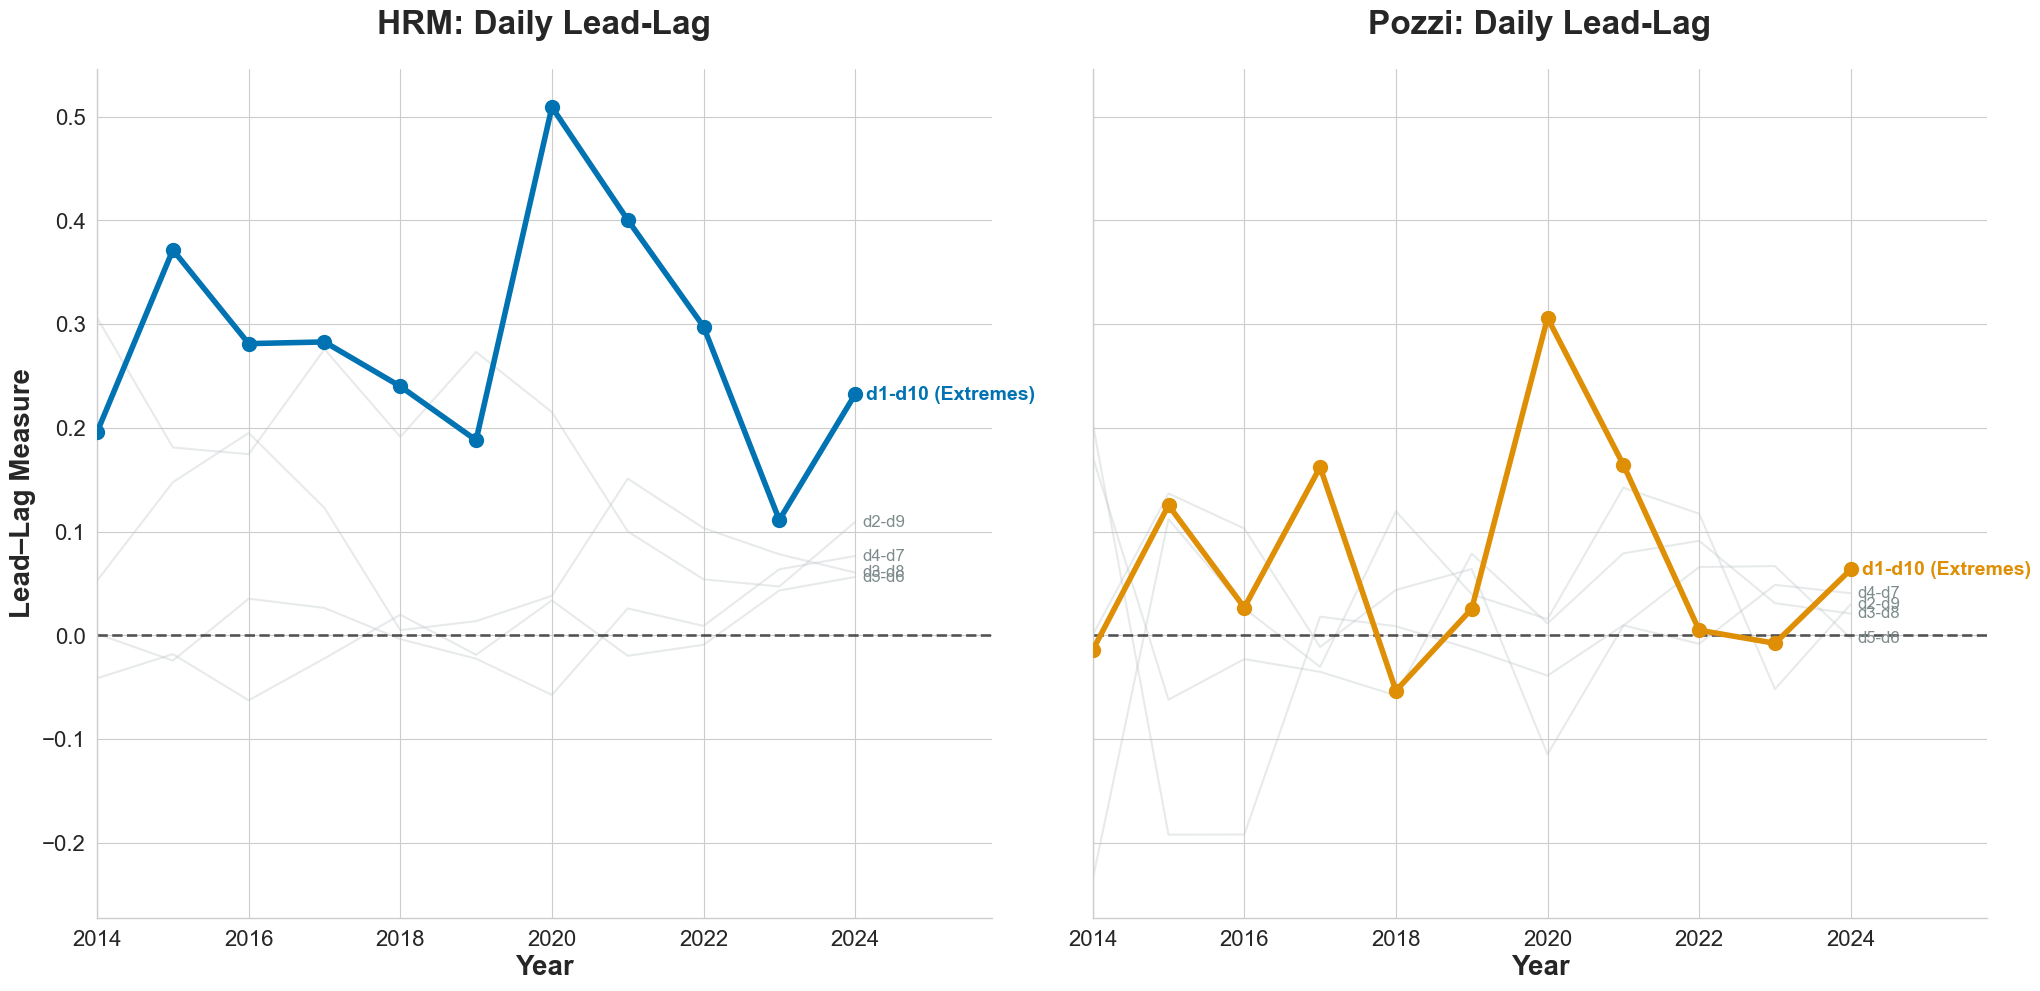

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
import os

# --- Style Configuration ---
sns.set_theme(style="whitegrid", context="paper")
palette = sns.color_palette("colorblind")

TITLE_SIZE = 24
LABEL_SIZE = 20
TICK_SIZE = 16
ANNOTATE_SIZE = 14
LINE_WIDTH_MAIN = 4.0
LINE_WIDTH_BACK = 1.5
MARKER_SIZE = 10

# Focando apenas no Daily Lead-Lag
col_df = "cp1d"
metrics_list = ["HRM", "Pozzi"]

# Uma linha, duas colunas
fig, axes = plt.subplots(1, 2, figsize=(22, 10), sharey=True)

metric_colors = {"HRM": palette[0], "Pozzi": palette[1]}

for col, metric_name in enumerate(metrics_list):
    ax = axes[col]
    data_dict = all_metrics_data[metric_name]
    main_color = metric_colors[metric_name]
    
    # 1. Pares intermediários (cinza)
    back_pairs = [("d2_d9", "d2-d9"), ("d3_d8", "d3-d8"), ("d4_d7", "d4-d7"), ("d5_d6", "d5-d6")]
    for pair_key, pair_label in back_pairs:
        if pair_key in data_dict:
            df_pair = data_dict[pair_key].dropna(subset=[col_df])
            if not df_pair.empty:
                ax.plot(df_pair.index, df_pair[col_df], color="#BDC3C7", 
                        lw=LINE_WIDTH_BACK, alpha=0.35, zorder=1)
                
                # Rótulo no fim da linha
                last_year = df_pair.index[-1]
                last_val = df_pair[col_df].iloc[-1]
                ax.annotate(pair_label, xy=(last_year, last_val), xytext=(5, 0),
                            textcoords='offset points', fontsize=ANNOTATE_SIZE-2, 
                            color="#7F8C8D", va='center')
    
    # 2. Par de destaque (d1_d10)
    if "d1_d10" in data_dict:
        df_main = data_dict["d1_d10"].dropna(subset=[col_df])
        if not df_main.empty:
            ax.plot(df_main.index, df_main[col_df], color=main_color,
                    lw=LINE_WIDTH_MAIN, marker="o", markersize=MARKER_SIZE, zorder=5)
            
            # Rótulo em destaque
            last_year = df_main.index[-1]
            last_val = df_main[col_df].iloc[-1]
            ax.annotate("d1-d10 (Extremes)", xy=(last_year, last_val), xytext=(8, 0),
                        textcoords='offset points', fontsize=ANNOTATE_SIZE, 
                        fontweight='bold', color=main_color, va='center')
    
    # --- Formatação ---
    ax.set_title(f"{metric_name}: Daily Lead-Lag", fontsize=TITLE_SIZE, fontweight="bold", pad=25)
    ax.set_xlabel("Year", fontsize=LABEL_SIZE, fontweight="bold")
    
    if col == 0:
        ax.set_ylabel("Lead–Lag Measure", fontsize=LABEL_SIZE, fontweight="bold")
    
    ax.tick_params(axis="both", labelsize=TICK_SIZE)
    ax.axhline(0, color="black", lw=2, ls="--", alpha=0.6)
    
    # Ajuste do limite X para os nomes não serem cortados
    ax.set_xlim(df_main.index.min(), df_main.index.max() + 1.8)

# Polimento final
sns.despine(fig=fig)
plt.tight_layout(rect=[0, 0, 0.94, 1])

os.makedirs("../../figures", exist_ok=True)
plt.savefig("../../figures/daily_leadlag_final_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

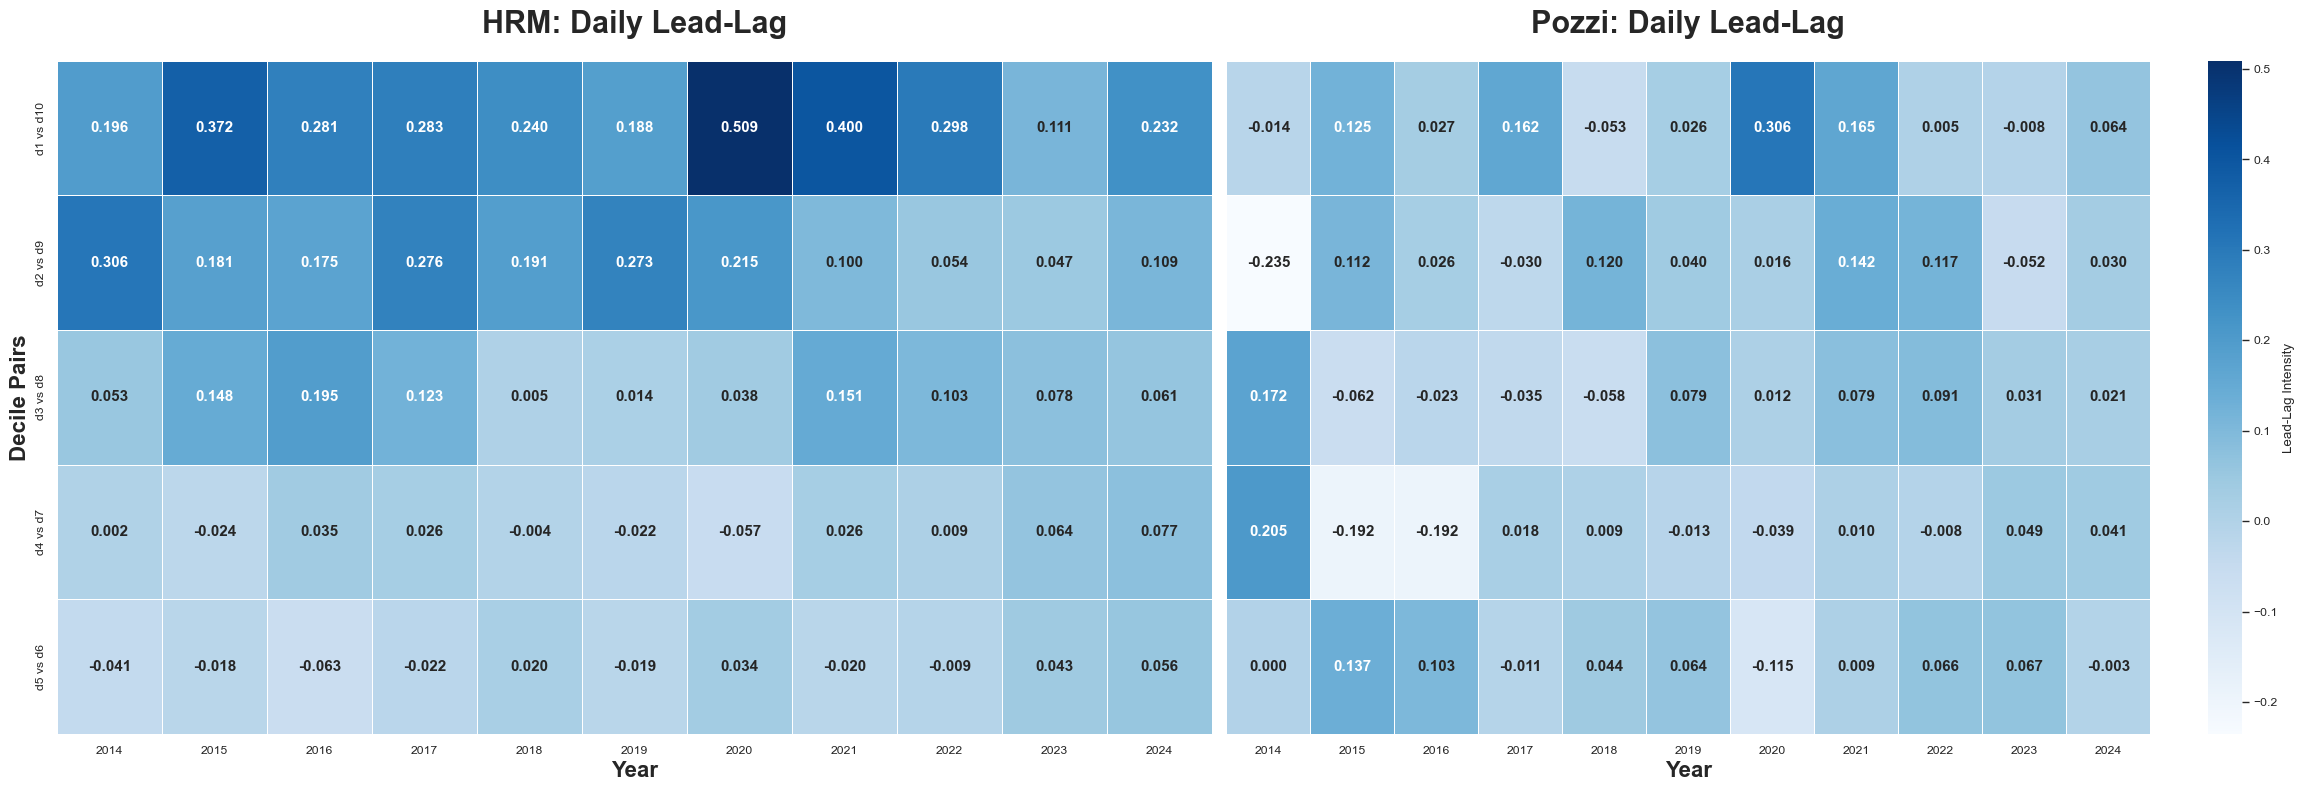

In [8]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import os

# --- Preparação dos Dados ---
metrics = ["HRM", "Pozzi"]
pairs = ["d1_d10", "d2_d9", "d3_d8", "d4_d7", "d5_d6"]
labels = ["d1 vs d10", "d2 vs d9", "d3 vs d8", "d4 vs d7", "d5 vs d6"]

# Dicionário para armazenar os DataFrames pivotados
matrices = {}

for metric in metrics:
    data_dict = hrm_results if metric == "HRM" else pozzi_results
    matrix_data = []
    for pair in pairs:
        series = data_dict[pair]['cp1d']
        matrix_data.append(series)
    
    df_m = pd.concat(matrix_data, axis=1)
    df_m.columns = labels
    matrices[metric] = df_m.T  # Index: Pares, Columns: Anos

# --- Cálculo dos Limites Globais para o Cmap ---
# Pegamos o mínimo e o máximo de todos os dados combinados para travar o Cmap
all_values = pd.concat([matrices["HRM"], matrices["Pozzi"]]).values
v_min = np.nanmin(all_values)
v_max = np.nanmax(all_values)

# --- Plotagem ---
fig, axes = plt.subplots(1, 2, figsize=(24, 8), sharey=True)

for idx, metric in enumerate(metrics):
    ax = axes[idx]
    
    sns.heatmap(
        matrices[metric], 
        ax=ax,
        cmap="Blues", 
        vmin=v_min,           # Limite inferior compartilhado
        vmax=v_max,           # Limite superior compartilhado
        annot=True, 
        fmt=".3f", 
        linewidths=.5, 
        # Adiciona a barra de cores apenas no segundo gráfico para economizar espaço
        cbar=(idx == 1),
        cbar_kws={'label': 'Lead-Lag Intensity'} if idx == 1 else {},
        annot_kws={"size": 11, "weight": "bold"}
    )
    
    ax.set_title(f"{metric}: Daily Lead-Lag", fontsize=22, fontweight="bold", pad=20)
    ax.set_xlabel("Year", fontsize=16, fontweight="bold")
    
    if idx == 0:
        ax.set_ylabel("Decile Pairs", fontsize=16, fontweight="bold")

plt.tight_layout()
os.makedirs("../../figures", exist_ok=True)
plt.savefig("../../figures/daily_leadlag_shared_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

In [16]:
import os
import pandas as pd

# Função auxiliar pra evitar repetir código
def load_files_mcap():
    df_list = []
    # Loop de 2015 a 2025
    for year in range(2015, 2026):
        file_path = f"../../data/08_lead_lag/marketcap_leadlag_df_{year}.csv"
        # Só lê se o arquivo existir na pasta
        if os.path.exists(file_path):
            df_list.append(pd.read_csv(file_path, index_col=0))
    return pd.concat(df_list)

# Carregando as diferentes variações
df_mcap = load_files_mcap()

In [17]:
df_mcap

,ls1d,ls1w,ls2w,ls1m
2015,-0.091985,-0.099372,-0.116267,-0.108881
2016,-0.082557,-0.101235,-0.096282,-0.098688
2017,-0.064492,-0.104122,-0.103934,-0.101725
2018,-0.045373,-0.062040,-0.086272,-0.013130
2019,-0.034277,-0.020927,0.000840,0.015865
2020,-0.040601,0.043985,-0.186469,-0.045378
2021,-0.033748,0.029825,-0.198023,-0.031361
2022,-0.035098,0.010477,-0.195309,-0.047091
2023,-0.044168,-0.005605,-0.197154,-0.030796
2024,-0.035927,-0.009498,-0.199481,-0.039394


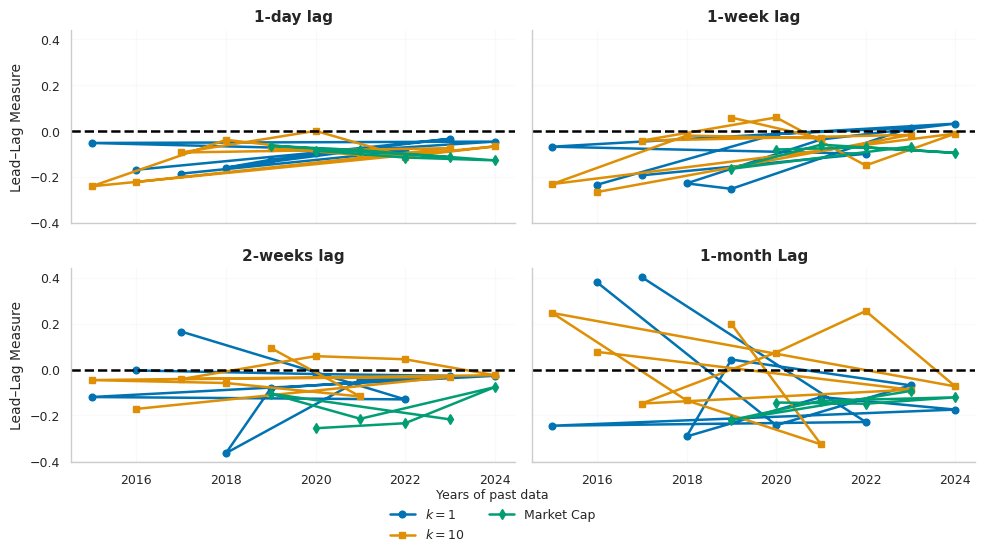

In [4]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# --- Style ---
sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)
palette = sns.color_palette("colorblind")

# --- Figure ---
fig, axes = plt.subplots(2, 2, figsize=(10, 5.5), sharex=True, sharey=True)
axes_flat = axes.flatten()  # ✦ key fix: iterate over individual axes

# -------- Panel config --------
panels = [
    ("cp1d", "ls1", "1-day lag"),
    ("cp1w", "ls2", "1-week lag"),
    ("cp2w", "ls3", "2-weeks lag"),
    ("cp1m", "ls4", "1-month Lag"),
]

for i, (ax, (col_cp, col_ls, title)) in enumerate(zip(axes_flat, panels)):
    l1, = ax.plot(
        df1.index, df1[col_cp],
        lw=1.8, color=palette[0],
        label="$k = 1$",
        marker="o"
    )

    l2, = ax.plot(
        df10.index, df10[col_cp],
        lw=1.8, color=palette[1],
        label="$k = 10$",
        marker="s"
    )

    l3, = ax.plot(
        dfmcap.index, dfmcap[col_cp],
        lw=1.8, color=palette[2],
        label="Market Cap",
        marker="d"
    )

    ax.set_title(title, fontsize=11, fontweight="bold", pad=6)
    ax.tick_params(axis="both", labelsize=9)
    ax.axhline(0, color="black", linewidth=1.8, linestyle="--")
    ax.set_xlabel("")

    # ✦ Only left-column panels get a y-label
    if i % 2 == 0:
        ax.set_ylabel("Lead–Lag Measure", fontsize=10)
    else:
        ax.set_ylabel("")
    
    ax.grid(alpha=0.1)

# -------- Single shared legend below all panels --------
handles = [l1, l2, l3]
fig.legend(
    handles,
    [h.get_label() for h in handles],
    loc="lower center",
    ncol=2,
    frameon=False,
    fontsize=9,
    title="Years of past data",
    title_fontsize=9,
    bbox_to_anchor=(0.5, -0.02),
)

# -------- Final polish --------
sns.despine(fig=fig)
plt.tight_layout(rect=[0, 0.07, 1, 1])
# plt.savefig(f"../../figures/leadlag_over_time.png", dpi=300)
plt.show()